# Production and Downtime Analysis

This is a manufacturing analytics project, the focus is on assessing the most influential root causes of downtime and production inefficiencies, using Python, Power BI and Six Sigma/Lean concepts to support wise decision making.



## Dataset Description

The dataset is called [“Manufacturing Efficiency in Downtime Operations”](https://www.kaggle.com/datasets/agungpambudi/predict-manufacturing-downtime-performance-dataset?select=downtime-factors.csv), available on kaggle.

**line-productivity.csv** - Fact table containing details for each batch produced
- Date: Date the batch was produced
- Product: ID for the product in the batch
- Batch: Unique ID for the batch produced
- Operator: Production line operator in charge of the batch
- Start Time: Time the batch production started
- End Time: Time the batch production ended

**products.csv** - Dimension table with details on each product
- Product: Unique product ID
- Flavor: Soda flavor for the product
- Size: Product size (volume)
- Min batch time: Minimum time required to produce a batch (with no downtime)

**line-downtime.csv** - Fact table containing downtime (in minutes) by factor for each batch
- Batch: Unique ID for the batch produced
- Downtime Factor: Downtime minutes for each factor ID (across columns)

**downtime-factors.csv** - Dimension table with details on each downtime factor
- Factor: Unique ID for each downtime factor
- Description: Downtime factor description
- Operator Error: Is this due to operator error? (Y/N)

In [1]:
import numpy as np
import pandas as pd
import datetime as dt
from datetime import timedelta

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
import notebook
print(notebook.__version__)

7.4.5


## 1. Data Cleaning

### Line Productivity Table

In [3]:
lp = pd.read_csv('../data/raw/line-productivity.csv', delimiter='|',index_col=0)
lp.head()

,Product,Batch,Operator,Start Time,End Time
Date,,,,,
2024-08-29,OR-600,422111,Mac,11:50:00,14:05:00
2024-08-29,LE-600,422112,Mac,14:05:00,15:45:00
2024-08-29,LE-600,422113,Mac,15:45:00,17:35:00
2024-08-29,LE-600,422114,Mac,17:35:00,19:15:00
2024-08-29,LE-600,422115,Charlie,19:15:00,20:39:00


In [4]:
# Change last value on 'End Time' and remove the 1900s date stamp
lp['End Time'].iloc[-1] = '01:05:00'

In [5]:
lp.columns

Index(['Product', 'Batch', 'Operator', 'Start Time', 'End Time'], dtype='object')

In [6]:
# Setting 'Date' as the Index and converting to datetime
lp.index = pd.to_datetime(lp.index)

In [7]:
lp.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 31 entries, 2024-08-29 to 2024-09-03
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Product     31 non-null     object
 1   Batch       31 non-null     int64 
 2   Operator    31 non-null     object
 3   Start Time  31 non-null     object
 4   End Time    31 non-null     object
dtypes: int64(1), object(4)
memory usage: 1.5+ KB


In [8]:
# Coverting Datatypes

lp['Start Time'] = pd.to_datetime(lp.index.strftime('%Y-%m-%d')+' '+lp['Start Time'])
lp['End Time'] = pd.to_datetime(lp.index.strftime('%Y-%m-%d')+' '+lp['End Time'])

# Let's not forget that the last value goes into AM hours and the day should shift
lp['End Time'].iloc[-1] = lp['End Time'].iloc[-1] + pd.DateOffset(days=1) 
lp.head()


,Product,Batch,Operator,Start Time,End Time
Date,,,,,
2024-08-29,OR-600,422111,Mac,2024-08-29 11:50:00,2024-08-29 14:05:00
2024-08-29,LE-600,422112,Mac,2024-08-29 14:05:00,2024-08-29 15:45:00
2024-08-29,LE-600,422113,Mac,2024-08-29 15:45:00,2024-08-29 17:35:00
2024-08-29,LE-600,422114,Mac,2024-08-29 17:35:00,2024-08-29 19:15:00
2024-08-29,LE-600,422115,Charlie,2024-08-29 19:15:00,2024-08-29 20:39:00


In [9]:
# Doesn't seem like we have much data, and indeed we only have a few weekdays with several shifts, so seasonality analysis and the like won't
# be possible with this dataset

lp['Weekday'] = lp.index.day_name()
lp.Weekday.unique()

array(['Thursday', 'Friday', 'Saturday', 'Monday', 'Tuesday'],
      dtype=object)

In [10]:
# Calculating Cycle Time

lp['Cycle_Time'] = lp['End Time'] - lp['Start Time']
lp.head()

,Product,Batch,Operator,Start Time,End Time,Weekday,Cycle_Time
Date,,,,,,,
2024-08-29,OR-600,422111,Mac,2024-08-29 11:50:00,2024-08-29 14:05:00,Thursday,0 days 02:15:00
2024-08-29,LE-600,422112,Mac,2024-08-29 14:05:00,2024-08-29 15:45:00,Thursday,0 days 01:40:00
2024-08-29,LE-600,422113,Mac,2024-08-29 15:45:00,2024-08-29 17:35:00,Thursday,0 days 01:50:00
2024-08-29,LE-600,422114,Mac,2024-08-29 17:35:00,2024-08-29 19:15:00,Thursday,0 days 01:40:00
2024-08-29,LE-600,422115,Charlie,2024-08-29 19:15:00,2024-08-29 20:39:00,Thursday,0 days 01:24:00


### Line Downtime Table

In [11]:
ld = pd.read_csv('../data/raw/line-downtime.csv', delimiter = '|', index_col = 0)
ld

,Factor 1,2,3,4,5,6,7,8,9,10,11,12
Batch,,,,,,,,,,,,
Batch,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
422111,NaN,60.0,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN
422112,NaN,20.0,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN
422113,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
422114,NaN,NaN,NaN,25.0,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN
422115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,NaN,NaN
422116,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
422117,NaN,10.0,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN
422118,NaN,NaN,NaN,NaN,NaN,14.0,16.0,NaN,NaN,NaN,10.0,20.0


In [12]:
ld = ld.rename(columns=ld.iloc[0])  # set first row as header
ld = ld[1:]                         # remove row
ld = ld.reset_index()               # set 'Batch' as its own column
ld.head()

,Batch,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
0,422111,NaN,60.0,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN
1,422112,NaN,20.0,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN
2,422113,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,422114,NaN,NaN,NaN,25.0,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN
4,422115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,NaN,NaN


In [13]:
# Get downtime per Batch
ld['Count']=(ld.count(axis=1))-1
ld['Sum']=ld.sum(axis=1, skipna =True, numeric_only=True)
ld.head()

,Batch,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,Count,Sum
0,422111,NaN,60.0,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN,2,77.0
1,422112,NaN,20.0,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN,2,42.0
2,422113,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,51.0
3,422114,NaN,NaN,NaN,25.0,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN,2,42.0
4,422115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,NaN,NaN,1,25.0


In [14]:
ld.info()  # notice how there are more batches than on the previous lp dataframe and 'Batch' is not int

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Batch   38 non-null     object 
 1   1.0     0 non-null      float64
 2   2.0     5 non-null      float64
 3   3.0     2 non-null      float64
 4   4.0     9 non-null      float64
 5   5.0     3 non-null      float64
 6   6.0     12 non-null     float64
 7   7.0     11 non-null     float64
 8   8.0     6 non-null      float64
 9   9.0     1 non-null      float64
 10  10.0    3 non-null      float64
 11  11.0    3 non-null      float64
 12  12.0    6 non-null      float64
 13  Count   38 non-null     int64  
 14  Sum     38 non-null     float64
dtypes: float64(13), int64(1), object(1)
memory usage: 4.6+ KB


In [15]:
# Converting datatypes
ld.Batch = ld.Batch.astype(int)
ld = ld.drop(ld[(ld.Batch > 422136) & (ld.Batch < 422144)].index) # removing downtime with no other production data
ld = ld.fillna(0)
ld.head()

,Batch,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,Count,Sum
0,422111,0.0,60.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,0.0,0.0,2,77.0
1,422112,0.0,20.0,0.0,0.0,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0,2,42.0
2,422113,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,51.0
3,422114,0.0,0.0,0.0,25.0,0.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,2,42.0
4,422115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,0.0,0.0,1,25.0


## 2. Data Modeling

### Unpivot the Line Downtime Table

In [16]:
ld.columns

Index(['Batch',     1.0,     2.0,     3.0,     4.0,     5.0,     6.0,     7.0,
           8.0,     9.0,    10.0,    11.0,    12.0, 'Count',   'Sum'],
      dtype='object')

In [17]:
uld = pd.melt(ld[['Batch',     1.0,     2.0,     3.0,     4.0,     5.0,     6.0,     7.0,
           8.0,     9.0,    10.0,    11.0,    12.0]], id_vars='Batch', var_name='Factor', value_name='Downtime')
uld.Factor = uld.Factor.astype(float)
uld.sort_values('Batch').head()

,Batch,Factor,Downtime
0,422111,1.0,0.0
279,422111,10.0,0.0
155,422111,6.0,0.0
93,422111,4.0,0.0
310,422111,11.0,0.0


### 

### Products Table

In [18]:
products = pd.read_csv('../data/raw/products.csv', delimiter='|', index_col=0)
products['Full Name'] = products.Flavor + ' ' + products.Size
products

,Flavor,Size,Min batch time,Full Name
Product,,,,
OR-600,Orange,600 ml,60,Orange 600 ml
LE-600,Lemon lime,600 ml,60,Lemon lime 600 ml
CO-600,Cola,600 ml,60,Cola 600 ml
DC-600,Diet Cola,600 ml,60,Diet Cola 600 ml
CO-2L,Cola,2 L,98,Cola 2 L


### Factors Table

In [19]:
factors = pd.read_csv('../data/raw/downtime-factors.csv', delimiter='|')
factors.Factor = factors.Factor.astype(float)
factors

,Factor,Description,Operator Error
0,1.0,Emergency stop,No
1,2.0,Batch change,Yes
2,3.0,Labeling error,No
3,4.0,Inventory shortage,No
4,5.0,Product spill,Yes
5,6.0,Machine adjustment,Yes
6,7.0,Machine failure,No
7,8.0,Batch coding error,Yes
8,9.0,Conveyor belt jam,No
9,10.0,Calibration error,Yes


### Batch-Product Time Table

Now let's make a table that allows us to easily compare and calculate time variations across Batch and Product.

In [20]:
bpt = (lp.groupby(["Product","Batch"])["Cycle_Time"].sum().reset_index(name="Batch_Time"))
bpt["Min_Batch_Time(m)"] = bpt.Product.apply(lambda x: 98 if x == "CO-2L" else 60)
bpt["Min_Batch_Time"] = pd.to_timedelta(bpt["Min_Batch_Time(m)"], unit="m")
bpt["Time_Sigma"] = bpt["Batch_Time"]-bpt["Min_Batch_Time"]
bpt["Batch_Time(m)"] = bpt["Batch_Time"].dt.total_seconds()/60
bpt["Time_Sigma(m)"] = bpt["Batch_Time(m)"] - bpt["Min_Batch_Time(m)"]
bpt = bpt[['Batch','Product','Batch_Time(m)','Min_Batch_Time(m)','Time_Sigma(m)','Batch_Time','Min_Batch_Time','Time_Sigma']]

bpt.head()

,Batch,Product,Batch_Time(m),Min_Batch_Time(m),Time_Sigma(m),Batch_Time,Min_Batch_Time,Time_Sigma
0,422144,CO-2L,152.0,98,54.0,0 days 02:32:00,0 days 01:38:00,0 days 00:54:00
1,422145,CO-2L,120.0,98,22.0,0 days 02:00:00,0 days 01:38:00,0 days 00:22:00
2,422146,CO-2L,160.0,98,62.0,0 days 02:40:00,0 days 01:38:00,0 days 01:02:00
3,422147,CO-2L,205.0,98,107.0,0 days 03:25:00,0 days 01:38:00,0 days 01:47:00
4,422148,CO-2L,130.0,98,32.0,0 days 02:10:00,0 days 01:38:00,0 days 00:32:00


In [21]:
bpt = pd.merge(bpt, ld[['Batch','Sum','Count']], left_on='Batch', right_on='Batch', how='left')
bpt = bpt.rename(columns={'Sum':'Total_Downtime'})
bpt = bpt.rename(columns={'Count':'Counts_Downtime'})
bpt.head()

,Batch,Product,Batch_Time(m),Min_Batch_Time(m),Time_Sigma(m),Batch_Time,Min_Batch_Time,Time_Sigma,Total_Downtime,Counts_Downtime
0,422144,CO-2L,152.0,98,54.0,0 days 02:32:00,0 days 01:38:00,0 days 00:54:00,56.0,2
1,422145,CO-2L,120.0,98,22.0,0 days 02:00:00,0 days 01:38:00,0 days 00:22:00,23.0,1
2,422146,CO-2L,160.0,98,62.0,0 days 02:40:00,0 days 01:38:00,0 days 01:02:00,65.0,3
3,422147,CO-2L,205.0,98,107.0,0 days 03:25:00,0 days 01:38:00,0 days 01:47:00,110.0,3
4,422148,CO-2L,130.0,98,32.0,0 days 02:10:00,0 days 01:38:00,0 days 00:32:00,34.0,2


### Batch-Operator Time Table

Now with the Operators.

In [22]:
bot = (lp.groupby(["Operator","Batch","Product"])["Cycle_Time"].sum().reset_index(name="Batch_Time"))
bot["Min_Batch_Time(m)"] = bot.Product.apply(lambda x: 98 if x == "CO-2L" else 60)
bot["Min_Batch_Time"] = pd.to_timedelta(bot["Min_Batch_Time(m)"], unit="m")
bot["Time_Sigma"] = bot["Batch_Time"]-bot["Min_Batch_Time"]
bot["Batch_Time(m)"] = bot["Batch_Time"].dt.total_seconds()/60
bot["Time_Sigma(m)"] = bot["Batch_Time(m)"] - bot["Min_Batch_Time(m)"]
bot = bot[['Batch','Operator','Batch_Time(m)','Min_Batch_Time(m)','Time_Sigma(m)','Batch_Time','Min_Batch_Time','Time_Sigma']]

bot.head()

,Batch,Operator,Batch_Time(m),Min_Batch_Time(m),Time_Sigma(m),Batch_Time,Min_Batch_Time,Time_Sigma
0,422115,Charlie,84.0,60,24.0,0 days 01:24:00,0 days 01:00:00,0 days 00:24:00
1,422116,Charlie,60.0,60,0.0,0 days 01:00:00,0 days 01:00:00,0 days 00:00:00
2,422117,Charlie,75.0,60,15.0,0 days 01:15:00,0 days 01:00:00,0 days 00:15:00
3,422125,Charlie,80.0,60,20.0,0 days 01:20:00,0 days 01:00:00,0 days 00:20:00
4,422126,Charlie,104.0,60,44.0,0 days 01:44:00,0 days 01:00:00,0 days 00:44:00


In [23]:
bot = pd.merge(bot, ld[['Batch','Sum','Count']], left_on='Batch', right_on='Batch', how='left')
bot = bot.rename(columns={'Sum':'Total_Downtime'})
bot = bot.rename(columns={'Count':'Counts_Downtime'})
bot.head()

,Batch,Operator,Batch_Time(m),Min_Batch_Time(m),Time_Sigma(m),Batch_Time,Min_Batch_Time,Time_Sigma,Total_Downtime,Counts_Downtime
0,422115,Charlie,84.0,60,24.0,0 days 01:24:00,0 days 01:00:00,0 days 00:24:00,25.0,1
1,422116,Charlie,60.0,60,0.0,0 days 01:00:00,0 days 01:00:00,0 days 00:00:00,0.0,0
2,422117,Charlie,75.0,60,15.0,0 days 01:15:00,0 days 01:00:00,0 days 00:15:00,17.0,2
3,422125,Charlie,80.0,60,20.0,0 days 01:20:00,0 days 01:00:00,0 days 00:20:00,22.0,2
4,422126,Charlie,104.0,60,44.0,0 days 01:44:00,0 days 01:00:00,0 days 00:44:00,45.0,1


## 3. Analysis and Visualizations

### Shift Distribution

Can we get a better view of the shifts across time, what was produced and by whom? - Yes.

In [24]:
fig = px.timeline(lp, x_start = "Start Time", x_end = "End Time", y = "Operator", color = "Product")
fig.show()

We can see that there is only one worker per batch or use the following snippet:

> `worker_count = (lp.groupby("Batch")["Operator"].nunique().reset_index(name='NumWorkers'))`

The shifts are very irregular, both in time, duration, operator...
The batches we have the downtime data for but no other production data coincide with times between Saturday and Monday. Could the missing data be related to turning off/on certain systems or neglecting procedures related to data collection by shutting down the production line for the Sunday / taking time to restart on Monday?

**Total Time Production - Sum of Cycle Times**

What is the total cycle time / time of production given in this dataset?

In [25]:
total_cycle_time = lp.Cycle_Time.sum()
total_cycle_time_m = (total_cycle_time.total_seconds())/60
total_cycle_time_h = (total_cycle_time.total_seconds())/3600

print("Total Time Production: ", total_cycle_time)
print("Total Time Production(m): ", total_cycle_time_m)
print("Total Time Production(h): ", total_cycle_time_h)

Total Time Production:  2 days 05:00:00
Total Time Production(m):  3180.0
Total Time Production(h):  53.0


**Total Cycle Time - Product**

How much of this time was spent on each product?

In [26]:
p_cycle_time = lp.groupby("Product")["Cycle_Time"].sum().reset_index()
p_cycle_time['Cycle_Time(m)'] = p_cycle_time['Cycle_Time'].dt.total_seconds().div(60).astype(float)
p_cycle_time['Cycle_Time(h)'] = p_cycle_time['Cycle_Time'].dt.total_seconds().div(60).div(60).astype(float)
p_cycle_time

,Product,Cycle_Time,Cycle_Time(m),Cycle_Time(h)
0,CO-2L,0 days 12:47:00,767.0,12.783333
1,CO-600,0 days 23:14:00,1394.0,23.233333
2,DC-600,0 days 05:55:00,355.0,5.916667
3,LE-600,0 days 08:49:00,529.0,8.816667
4,OR-600,0 days 02:15:00,135.0,2.250000


**Average Cycle Time - Product**

What was the average time per product? The minimum amount of time it takes to complete is 60 minutes, except for CO-2L, which takes 98 minutes (this would be the ideal scenario, naturally it will always take more as some processes, like preparing gear for another batch, cannot be eliminated, only streamlined). 

In [27]:
p_avg_ct = (
    lp.groupby(["Product", "Batch"])["Cycle_Time"].sum()
    .groupby("Product").mean().reset_index(name="AvgCycleTime")
)
p_avg_ct['AvgCycle_Time(m)'] = p_avg_ct['AvgCycleTime'].dt.total_seconds().div(60).astype(float)
p_avg_ct['AvgCycle_Time(h)'] = p_avg_ct['AvgCycleTime'].dt.total_seconds().div(60).div(60).astype(float)
p_avg_ct

,Product,AvgCycleTime,AvgCycle_Time(m),AvgCycle_Time(h)
0,CO-2L,0 days 02:33:24,153.400000,2.556667
1,CO-600,0 days 01:32:56,92.933333,1.548889
2,DC-600,0 days 01:28:45,88.750000,1.479167
3,LE-600,0 days 01:28:10,88.166667,1.469444
4,OR-600,0 days 02:15:00,135.000000,2.250000


**Total Hours Production - Operator**

How many hours have our Operators worked so far?

In [28]:
o_cycle_time = (
    lp.groupby("Operator")["Cycle_Time"].sum().reset_index())
o_cycle_time['Cycle_Time(m)'] = o_cycle_time['Cycle_Time'].dt.total_seconds().div(60).astype(float)
o_cycle_time['Cycle_Time(h)'] = o_cycle_time['Cycle_Time'].dt.total_seconds().div(60).div(60).astype(float)
o_cycle_time

,Operator,Cycle_Time,Cycle_Time(m),Cycle_Time(h)
0,Charlie,0 days 19:18:00,1158.0,19.300000
1,Dee,0 days 10:27:00,627.0,10.450000
2,Dennis,0 days 09:05:00,545.0,9.083333
3,Mac,0 days 14:10:00,850.0,14.166667


### Downtime per Factor

- How much total downtime per factor?
- How much time out of the total downtime is that? (percentage)
- What kind of downtime factor is more frequent?

In [29]:
uld_factor = (
    uld.groupby(["Factor"])["Downtime"].
    agg(
        Sum_dt_per_Factor='sum',
    )
    .reset_index()
)

uld_factor = pd.merge(uld_factor, factors, left_on='Factor', right_on='Factor', how='left')

uld_factor.sort_values('Sum_dt_per_Factor', ascending=False)

,Factor,Sum_dt_per_Factor,Description,Operator Error
6,7.0,236.0,Machine failure,No
3,4.0,205.0,Inventory shortage,No
5,6.0,197.0,Machine adjustment,Yes
1,2.0,160.0,Batch change,Yes
7,8.0,115.0,Batch coding error,Yes
11,12.0,67.0,Other,No
4,5.0,57.0,Product spill,Yes
9,10.0,34.0,Calibration error,Yes
2,3.0,22.0,Labeling error,No
10,11.0,20.0,Label switch,Yes


In [30]:
sum_of_downtime_m = uld_factor.Sum_dt_per_Factor.sum()
uld_factor['Percentage'] = (uld_factor['Sum_dt_per_Factor']*100)/sum_of_downtime_m
uld_factor.sort_values('Sum_dt_per_Factor', ascending=False)

,Factor,Sum_dt_per_Factor,Description,Operator Error,Percentage
6,7.0,236.0,Machine failure,No,20.884956
3,4.0,205.0,Inventory shortage,No,18.141593
5,6.0,197.0,Machine adjustment,Yes,17.433628
1,2.0,160.0,Batch change,Yes,14.159292
7,8.0,115.0,Batch coding error,Yes,10.176991
11,12.0,67.0,Other,No,5.929204
4,5.0,57.0,Product spill,Yes,5.044248
9,10.0,34.0,Calibration error,Yes,3.008850
2,3.0,22.0,Labeling error,No,1.946903
10,11.0,20.0,Label switch,Yes,1.769912


**Getting the Frequency per Factor**

In [31]:
#Let's get the count() from the previous df(ld) and add it to uld_factor
count_col = ld[ld != 0].count(axis=0)
count_col = count_col.iloc[1:13].to_frame()
count_col[0].index = count_col[0].index-1
uld_factor['Downtime_Count'] = count_col[0]
uld_factor.sort_values('Sum_dt_per_Factor', ascending=False)

,Factor,Sum_dt_per_Factor,Description,Operator Error,Percentage,Downtime_Count
6,7.0,236.0,Machine failure,No,20.884956,10
3,4.0,205.0,Inventory shortage,No,18.141593,8
5,6.0,197.0,Machine adjustment,Yes,17.433628,8
1,2.0,160.0,Batch change,Yes,14.159292,5
7,8.0,115.0,Batch coding error,Yes,10.176991,5
11,12.0,67.0,Other,No,5.929204,5
4,5.0,57.0,Product spill,Yes,5.044248,3
9,10.0,34.0,Calibration error,Yes,3.008850,2
2,3.0,22.0,Labeling error,No,1.946903,1
10,11.0,20.0,Label switch,Yes,1.769912,2


**Lean Manufacturing 8 Wastes**

The Lean Manufacturing 8 Wastes sorts various kinds of downtime factors into different types of waste:

- D: defects
- O: overproduction
- W: waiting
- N: non-utilized talend or skills
- T: transportation
- I: inventory
- M: motion
- E: extra-processing
  
It allows to transform a myriad of downtime factors into structured, actionable items.
We can later apply the Paretto principle and decide where to spend money tackling the most pressing issues.

In [32]:
# Sorting the Factors according to the 8 Wastes Framework
wastes = ['Waiting','Extra-Processing','Defects','Inventory, Waiting','Defects','Extra-Processing','Waiting','Defects','Waiting','Defects, Extra-Processing','Defects','Undefined']

uld_factor['Waste Type'] = wastes
uld_factor

,Factor,Sum_dt_per_Factor,Description,Operator Error,Percentage,Downtime_Count,Waste Type
0,1.0,0.0,Emergency stop,No,0.000000,0,Waiting
1,2.0,160.0,Batch change,Yes,14.159292,5,Extra-Processing
2,3.0,22.0,Labeling error,No,1.946903,1,Defects
3,4.0,205.0,Inventory shortage,No,18.141593,8,"Inventory, Waiting"
4,5.0,57.0,Product spill,Yes,5.044248,3,Defects
5,6.0,197.0,Machine adjustment,Yes,17.433628,8,Extra-Processing
6,7.0,236.0,Machine failure,No,20.884956,10,Waiting
7,8.0,115.0,Batch coding error,Yes,10.176991,5,Defects
8,9.0,17.0,Conveyor belt jam,No,1.504425,1,Waiting
9,10.0,34.0,Calibration error,Yes,3.008850,2,"Defects, Extra-Processing"


In [33]:
# Exploring if downtime periods by factor are all the same or vary a lot - they vary a lot.
for col in ld[[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0]]:
    print(col)
    print(ld[col].unique())

1.0
[0.]
2.0
[60. 20. 50.  0. 10.]
3.0
[ 0. 22.]
4.0
[ 0. 25. 20. 43. 30. 17.]
5.0
[ 0. 15. 20. 22.]
6.0
[ 0. 15.  5. 14. 20. 23. 30. 60.]
7.0
[15.  0. 16. 25. 30. 20.]
8.0
[ 0. 20. 44. 24.  7.]
9.0
[ 0. 17.]
10.0
[ 0. 24. 10.]
11.0
[ 0. 10.]
12.0
[ 0. 20. 10. 15.  7.]


In [34]:
#exploding the table to get the proper counts
uld_factor['Waste Type'] = uld_factor['Waste Type'].str.split(', ')
exploded = uld_factor.explode('Waste Type')
waste_frequency = exploded.groupby('Waste Type')['Downtime_Count'].sum().sort_values(ascending=False)
waste_frequency = waste_frequency.to_frame()

In [35]:
waste_frequency

,Downtime_Count
Waste Type,
Waiting,19
Extra-Processing,15
Defects,13
Inventory,8
Undefined,5


In [36]:
time_per_waste = exploded.groupby('Waste Type')['Sum_dt_per_Factor'].sum().sort_values(ascending=False)
time_per_waste = time_per_waste.to_frame()

In [37]:
time_per_waste['Percentage'] = (time_per_waste['Sum_dt_per_Factor']*100)/sum_of_downtime_m
time_per_waste

,Sum_dt_per_Factor,Percentage
Waste Type,,
Waiting,458.0,40.530973
Extra-Processing,391.0,34.601770
Defects,248.0,21.946903
Inventory,205.0,18.141593
Undefined,67.0,5.929204


Notice that the percentages don't add up, as some of the wastes have 2 categories in and at this point we cannot determine which would fit the case best. We can, however, get a rough estimate on what are the major contributions.

### Downtime per Batch

How can we quickly see the biggest downtime culprit? - Heatmap.

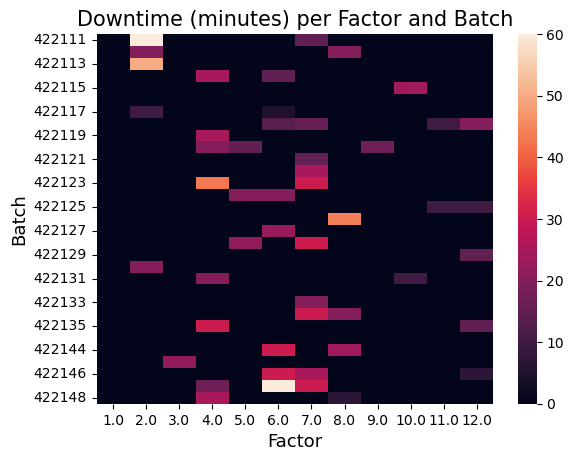

In [38]:
factor_batch_heatmap = ld[['Batch', 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0,]]
factor_batch_heatmap = factor_batch_heatmap.set_index("Batch")

ax = sns.heatmap(factor_batch_heatmap) 

plt.title('Downtime (minutes) per Factor and Batch', fontsize = 15) 
plt.xlabel('Factor', fontsize = 13) 
plt.ylabel('Batch', fontsize = 13) 

plt.show()

The Factors that contribute the most to downtime are 7, 6, 4 and 2.

**Dowtime per Batch**

Which Batch production has the highest downtime value?

In [39]:
## Max, Min and Ordered by Most Time Consuming
print("Highest downtime per Batch: ",bpt.Total_Downtime.max())
print("Lowest downtime per Batch: ",bpt.Total_Downtime.min())
bpt.sort_values('Total_Downtime', ascending=False).head()

Highest downtime per Batch:  110.0
Lowest downtime per Batch:  0.0


,Batch,Product,Batch_Time(m),Min_Batch_Time(m),Time_Sigma(m),Batch_Time,Min_Batch_Time,Time_Sigma,Total_Downtime,Counts_Downtime
3,422147,CO-2L,205.0,98,107.0,0 days 03:25:00,0 days 01:38:00,0 days 01:47:00,110.0,3
30,422111,OR-600,135.0,60,75.0,0 days 02:15:00,0 days 01:00:00,0 days 01:15:00,77.0,2
10,422123,CO-600,133.0,60,73.0,0 days 02:13:00,0 days 01:00:00,0 days 01:13:00,75.0,2
2,422146,CO-2L,160.0,98,62.0,0 days 02:40:00,0 days 01:38:00,0 days 01:02:00,65.0,3
5,422118,CO-600,120.0,60,60.0,0 days 02:00:00,0 days 01:00:00,0 days 01:00:00,64.0,4


**Frequency of Downtime per Batch**

Which Batch had most downtime instances?
How many dowtime instances in total?

In [40]:
## Max, Min and Ordered by Most Time Consuming
print("Most Frequent per Batch: ",bpt.Counts_Downtime.max())
print("Least Frequent per Batch: ",bpt.Counts_Downtime.min())
print("Total Counts of Dowtime: ",bpt.Counts_Downtime.sum())
bpt.sort_values('Counts_Downtime', ascending=False).head()

Most Frequent per Batch:  4
Least Frequent per Batch:  0
Total Counts of Dowtime:  50


,Batch,Product,Batch_Time(m),Min_Batch_Time(m),Time_Sigma(m),Batch_Time,Min_Batch_Time,Time_Sigma,Total_Downtime,Counts_Downtime
5,422118,CO-600,120.0,60,60.0,0 days 02:00:00,0 days 01:00:00,0 days 01:00:00,64.0,4
2,422146,CO-2L,160.0,98,62.0,0 days 02:40:00,0 days 01:38:00,0 days 01:02:00,65.0,3
3,422147,CO-2L,205.0,98,107.0,0 days 03:25:00,0 days 01:38:00,0 days 01:47:00,110.0,3
7,422120,CO-600,112.0,60,52.0,0 days 01:52:00,0 days 01:00:00,0 days 00:52:00,55.0,3
0,422144,CO-2L,152.0,98,54.0,0 days 02:32:00,0 days 01:38:00,0 days 00:54:00,56.0,2


Comparing the values of 'Time Sigma' and 'Downtime' we can see that they are roughly the same.

### Downtime per Product

- How much downtime per Product? How many instances?
- How much space does it take out of the total production time? OR-600 is higher than the others, but keep in mind only one Batch was produced.

In [41]:
product_downtime = bpt.groupby(['Product']).sum().drop('Batch',axis=1).sort_values("Total_Downtime", ascending=False)
product_downtime['hhmm_Downtime'] = product_downtime['Total_Downtime'].apply(lambda x: timedelta(minutes=x))
product_downtime[['Total_Downtime','hhmm_Downtime','Counts_Downtime']]

,Total_Downtime,hhmm_Downtime,Counts_Downtime
Product,,,
CO-600,518.0,0 days 08:38:00,24
CO-2L,288.0,0 days 04:48:00,11
LE-600,177.0,0 days 02:57:00,8
DC-600,120.0,0 days 02:00:00,5
OR-600,77.0,0 days 01:17:00,2


In [42]:
product_downtime['Downtime_Percentage(%)'] = (product_downtime['Total_Downtime']*100)/product_downtime['Batch_Time(m)']
product_downtime[['Batch_Time(m)','Total_Downtime','Downtime_Percentage(%)']]

,Batch_Time(m),Total_Downtime,Downtime_Percentage(%)
Product,,,
CO-600,1394.0,518.0,37.159254
CO-2L,767.0,288.0,37.548892
LE-600,529.0,177.0,33.459357
DC-600,355.0,120.0,33.802817
OR-600,135.0,77.0,57.037037


### Production Data - Products

- How many batches of a certain product were produced?
- How can we observe the distribution of how much time per each product it took? - Violinplot.

In [43]:
count_batch_product = lp.groupby('Product').count()
count_batch_product = count_batch_product[['Batch']]
count_batch_product

,Batch
Product,
CO-2L,5
CO-600,15
DC-600,4
LE-600,6
OR-600,1


<Axes: xlabel='Product', ylabel='Batch_Time(m)'>

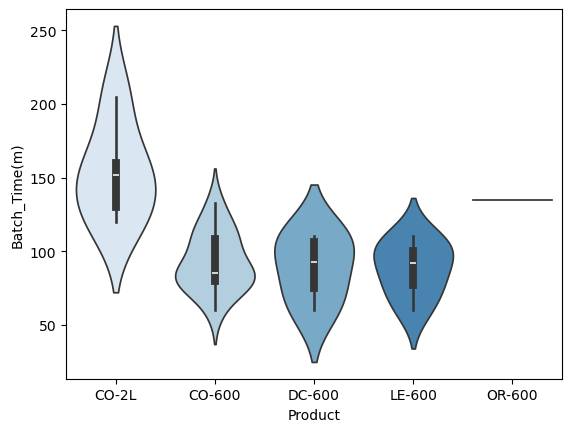

In [44]:
sns.violinplot(x="Product", y="Batch_Time(m)", data=bpt, palette="Blues")

We can immediately spot that only one batch of OR-600 was produced. The CO-2L has higher Cycle Time as expected as it is the batch type that takes the most time to finish. CO-2L and CO-600 seem to be the products that managed to stay closer to the minimum cycle time when being produced. 

### Downtime per Operator

- How much downtime per Operator? How many instances?
- How much space does it take out of the total production time?

In [45]:
operator_downtime = bot.groupby(['Operator']).sum().drop('Batch',axis=1).sort_values("Total_Downtime", ascending=False)
operator_downtime['hhmm_Downtime'] = operator_downtime['Total_Downtime'].apply(lambda x: timedelta(minutes=x))
operator_downtime[['Total_Downtime','hhmm_Downtime','Counts_Downtime']].sort_values('Counts_Downtime')

,Total_Downtime,hhmm_Downtime,Counts_Downtime
Operator,,,
Dennis,215.0,0 days 03:35:00,8
Dee,219.0,0 days 03:39:00,12
Mac,345.0,0 days 05:45:00,13
Charlie,401.0,0 days 06:41:00,17


In [46]:
operator_downtime['Downtime_Percentage(%)'] = (operator_downtime['Total_Downtime']*100)/operator_downtime['Batch_Time(m)']
operator_downtime[['Batch_Time(m)','Total_Downtime','Downtime_Percentage(%)']].sort_values('Downtime_Percentage(%)')

,Batch_Time(m),Total_Downtime,Downtime_Percentage(%)
Operator,,,
Charlie,1158.0,401.0,34.628670
Dee,627.0,219.0,34.928230
Dennis,545.0,215.0,39.449541
Mac,850.0,345.0,40.588235


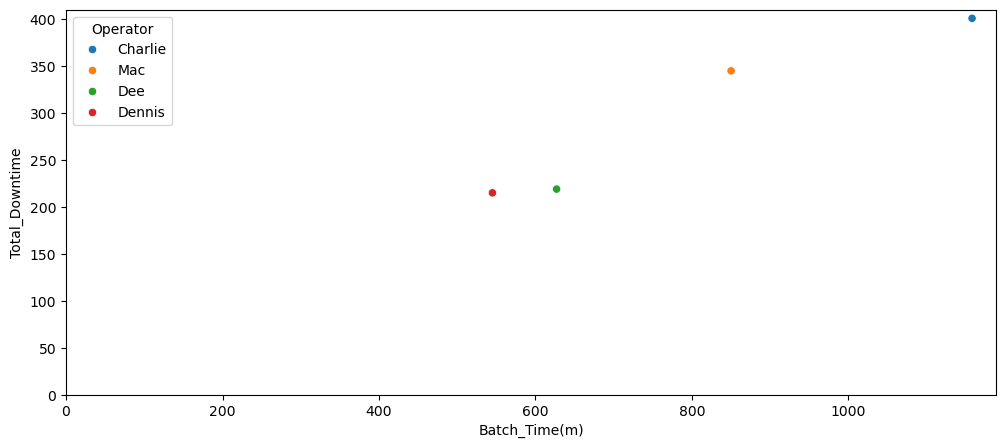

In [47]:
fig, ax = plt.subplots(figsize=(12,5))
sns.scatterplot(data=operator_downtime,x='Batch_Time(m)',y='Total_Downtime',hue='Operator',ax=ax)
ax.set_xlim(0,None)
ax.set_ylim(0,None)
plt.show()

The trend is to accumulate more downtime as you work more hours, yet we can see some variance - could experience/inexperience influence these shifts? Mac has the most downtime relative to worked hours and Charlie has the least. To explore further, the next step is to calculate how many of the downtime instances were 'Operator Error'. Let's see if there is a difference. This will show where clearer instructions, training and communication might be needed.

**Operator Error**

In [48]:
# Let's merge the unpivoted line downtime df and get the operators mapped in
op_factors = pd.merge(uld, bot[['Batch','Operator']], left_on='Batch', right_on='Batch', how='left')

# Getting the Factor ID that are not Operator Errors
fac = factors["Factor"][factors["Operator Error"]=='No'].tolist()

# And removing them from the df
op_factors = op_factors[~op_factors['Factor'].isin(fac)]
op_factors.head()

,Batch,Factor,Downtime,Operator
31,422111,2.0,60.0,Mac
32,422112,2.0,20.0,Mac
33,422113,2.0,50.0,Mac
34,422114,2.0,0.0,Mac
35,422115,2.0,0.0,Charlie


In [49]:
#Counts of downtime that are Operator Error
op_factors[op_factors["Downtime"] != 0.0].groupby(["Operator"])["Downtime"].count().reset_index().sort_values("Downtime")

,Operator,Downtime
2,Dennis,4
1,Dee,5
3,Mac,7
0,Charlie,9


In [50]:
#Sum of downtime that is Operator Error
op_factors_grouped = op_factors.groupby(["Operator"])["Downtime"].sum().reset_index().sort_values("Downtime", ascending=False)
#merge and get downtime percentage
op_factors_grouped = pd.merge(op_factors_grouped, operator_downtime['Batch_Time(m)'], left_on='Operator', right_on='Operator', how='left')
op_factors_grouped
op_factors_grouped['Downtime_Percentage(%)'] = (op_factors_grouped['Downtime']*100)/op_factors_grouped['Batch_Time(m)']
op_factors_grouped.sort_values('Downtime_Percentage(%)')

,Operator,Downtime,Batch_Time(m),Downtime_Percentage(%)
3,Dee,69.0,627.0,11.004785
2,Dennis,94.0,545.0,17.247706
0,Charlie,228.0,1158.0,19.689119
1,Mac,192.0,850.0,22.588235


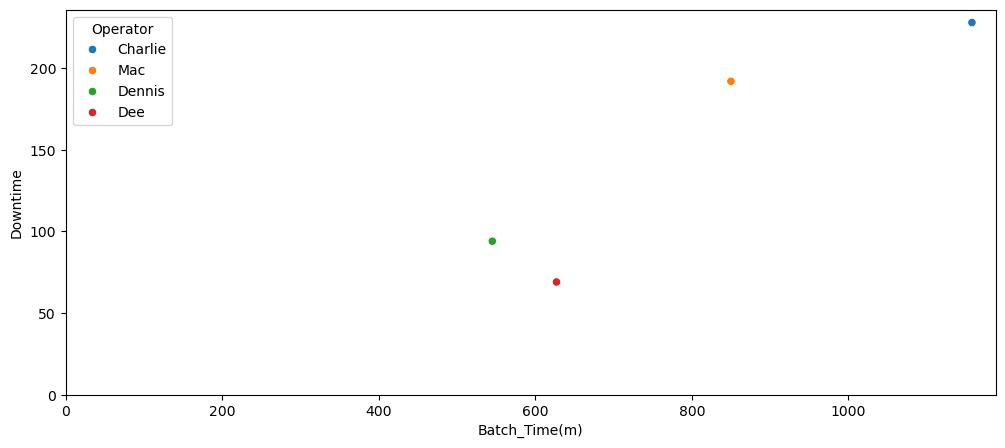

In [51]:
fig, ax = plt.subplots(figsize=(12,5))
sns.scatterplot(data=op_factors_grouped,x='Batch_Time(m)',y='Downtime',hue='Operator',ax=ax)
ax.set_xlim(0,None)
ax.set_ylim(0,None)
plt.show()

Now the stats have changed and Dee is the one with the least downtime.

### Productivity - Operator

- How many batches did each operator produce so far?

In [52]:
count_batch_operator = lp.groupby('Operator').count()
count_batch_operator = count_batch_operator[['Batch']]
count_batch_operator

,Batch
Operator,
Charlie,11
Dee,7
Dennis,5
Mac,8


**Statistics Summary**

In [53]:
print("TIME")
print("Total Downtime (minutes): ",uld_factor.Sum_dt_per_Factor.sum())
print("Total Downtimes (hours): ~",round(uld_factor.Sum_dt_per_Factor.sum()/60))
print("Highest downtime per Factor: ",uld_factor.Sum_dt_per_Factor.max())
idx = uld_factor['Sum_dt_per_Factor'].idxmax()
description = uld_factor.loc[idx,'Description']
print("The culprit: ",description)
print("FREQUENCY")
print("Total Instances of Downtime: ",uld_factor['Downtime_Count'].sum())
print("Most Instances of Downtime: ",uld_factor['Downtime_Count'].max())
idx2 = uld_factor['Downtime_Count'].idxmax()
description2 = uld_factor.loc[idx2,'Description']
print("The culprit: ", description2)
print("OPERATOR")
print("Most instances per Operator: ",operator_downtime.Counts_Downtime.max())
print("Total Operator Error Instances: ",uld_factor['Downtime_Count'][uld_factor['Operator Error']=='Yes'].sum())
print("8 WASTES")
print(f"Most Prevalent Waste: {waste_frequency.index[0]} - {waste_frequency.Downtime_Count.max()} times")

TIME
Total Downtime (minutes):  1130.0
Total Downtimes (hours): ~ 19
Highest downtime per Factor:  236.0
The culprit:  Machine failure
FREQUENCY
Total Instances of Downtime:  50
Most Instances of Downtime:  10
The culprit:  Machine failure
OPERATOR
Most instances per Operator:  17
Total Operator Error Instances:  25
8 WASTES
Most Prevalent Waste: Waiting - 19 times


### Downtime (%)

In [54]:
downtime_percentage = (sum_of_downtime_m * 100)/total_cycle_time_m
print(f"Downtime (%): {downtime_percentage}% ")

Downtime (%): 35.534591194968556% 


### Availability and Overall Equipment Efficiency (OEE)

Given that:
- Operating time is the difference between planned production time and unplanned downtime, and
- Availability is the ratio Between Operating Time and Planned Production Time:

In [55]:
operating_time = total_cycle_time_m - sum_of_downtime_m
availability = (operating_time / total_cycle_time_m)*100
print("Operating Time: ", operating_time)
print("Availability: ", availability)

Operating Time:  2050.0
Availability:  64.46540880503144


The Availability is low and indicates that over 30% of the time is spent on malfunctions, idle and/or not producing.

### Pareto Analysis

- According to the previous analysis we can conclude that the top 3 culprits of Waste sit in the 'Waiting', 'Extra-processing' and 'Defects' categories.
- Over 70% of downtime occurs due to Machine Failure, Inventory Shortage, Machine Adjustment and Batch Change.


# Conclusion


**On the Data**

- The data is scarce, yet provides an acceptable base for performing several analysis and establishing a foundation on what kind of system could be used to gather, process and get insights (were there more data available).
  
- Batches 422137 to 422146 are only present in the downtime table, which would fit between Saturday and Monday: possible data loss due to shutting down / turning on the production line before / after Sunday

- Working Hours and Operators seem random

- Only one Batch is producted at a time

- Only one Operator per Batch


**On Productivity and Downtime**

- The more time spent producing a Product, the more downtime - no significant anomalies that stand out
- The more time spent working by an Operator, the more downtime they experience - no significant anomalies
  


- Certain Downtime Factors are more prevalent than others. The main issues are <ins>'Machine Failure, 'Inventory Shortage', 'Macine Adjustment' and 'Batch Change'</ins>.
  

**Suggestions:**

- Autonomous Maintenance: Train operators to perform simples tasks of machine maintenance and most common repairs,
- Preventive Scheduling: Schedule maintenance based on machine runtime,
  
- Optimize Prep Time by having the necessary gear closer, well stored, having set and clear procedures,
- Apply forecasting systems to better predict inventory shortages - order more material preventively, produce another product instead of being idle, and
- Keep Buffer Inventory.
  
**Waste**

- The main Waste Types were determined and the most time consuming and the most frequent coincide.
  
- Waiting and Defects are a dangerous combination as waiting creates an urge to rush and catch up with time, and defects cause more waiting due to rework.
  

**Next Steps:**
- Perform Value Stream Mapping to audit the entire production process,
- Cross-Training employees so that they can have more autonomy and allocate their time to solving the most pressing bottleneck,
- Standardized Working practices, so that everyone is on the same page and documents can be consulted.



- Overall, the downtime is too high for what would be considered average or acceptable in the manufacturing industry and it is critical to improve OEE.





**Saving the new tables**

In [56]:
#line-productivity (lp)
lp.to_csv('../data/cleaned/line_productivity.csv')

#unpivoted line-downtime x factors (uld_factor)
uld_factor.to_csv('../data/cleaned/line_downtime_factors.csv')

#batch-product-time (bpt)
bpt.to_csv('../data/cleaned/batch_product_time.csv')

#batch-operator-time(bot)
bot.to_csv('../data/cleaned/batch_operator_time.csv')

#waste in terms of frequency (waste_frequency)
waste_frequency.to_csv('../data/cleaned/waste_frequency.csv')

#waste in terms of time (time_per_waste)
time_per_waste.to_csv('../data/cleaned/waste_timespan.csv')
